# K-Means Clustering Model - Load and Apply

This notebook loads the pre-trained K-Means clustering model (2010-2011 with weekly normalization) and applies it to new data or visualizes the training results.

**Features:**
- Load trained K-Means model from pickle file
- Apply clustering to new time periods
- Visualize clusters on maps
- Analyze cluster characteristics

## 1. Setup and Imports

In [1]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy.stats import binned_statistic_2d
from scipy.interpolate import RegularGridInterpolator
import pickle
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm, rgb2hex

import sys
sys.dont_write_bytecode = True
sys.path.append(os.path.abspath(".."))

from pipelines.l3_pipeline import L3DatasetLoader
from pipelines.l2_pipeline import L2DatasetLoader, GPUDataExtractor

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Trained Model

In [2]:
# Load the trained K-Means model
model_path = r"E:\satdata\Custom\kmeans_model_2010_2011_weekly.pkl"

print("Loading trained model...")
with open(model_path, 'rb') as f:
    model_data = pickle.load(f)

# Extract model components
kmeans = model_data['kmeans_model']
scaler = model_data['scaler']
lat_centers = model_data['lat_centers']
lon_centers = model_data['lon_centers']
lat_edges = model_data['lat_edges']
lon_edges = model_data['lon_edges']
bbox = model_data['bbox']
grid_shape = model_data['grid_shape']
n_clusters = model_data['n_clusters']
training_years = model_data['training_years']
cluster_centers = model_data['cluster_centers']
inertia = model_data['inertia']
weekly_stats = model_data.get('weekly_stats', None)

lon_min, lon_max, lat_min, lat_max = bbox
lat_bins, lon_bins = grid_shape

print("\n" + "=" * 80)
print("MODEL INFORMATION")
print("=" * 80)
print(f"  Training period: {training_years[0]}-{training_years[-1]} (June-November)")
print(f"  Region: [{lon_min}, {lat_min}] to [{lon_max}, {lat_max}]")
print(f"  Grid: {lat_bins} x {lon_bins}")
print(f"  Algorithm: K-means")
print(f"  Clusters: {n_clusters}")
print(f"  Normalization: Weekly (by week's high/low SST)")
print(f"  Iterations: {kmeans.n_iter_}")
print(f"  Inertia: {inertia:.2f}")
if weekly_stats:
    print(f"  Weekly stats: {len(weekly_stats)} weeks")
print("=" * 80)

Loading trained model...

MODEL INFORMATION
  Training period: 2005-2011 (June-November)
  Region: [-94.0, 27.5] to [-88.0, 30.5]
  Grid: 200 x 300
  Algorithm: K-means
  Clusters: 3
  Normalization: Weekly (by week's high/low SST)
  Iterations: 4
  Inertia: 263.46
  Weekly stats: 190 weeks

MODEL INFORMATION
  Training period: 2005-2011 (June-November)
  Region: [-94.0, 27.5] to [-88.0, 30.5]
  Grid: 200 x 300
  Algorithm: K-means
  Clusters: 3
  Normalization: Weekly (by week's high/low SST)
  Iterations: 4
  Inertia: 263.46
  Weekly stats: 190 weeks


## 3. Visualize Training Data Clusters

In [26]:
# Recreate cluster map from training data
training_labels = model_data['training_labels']
training_sst = model_data['training_sst']
training_chlor = model_data['training_chlor']

# Create colormap for clusters
unique_labels = sorted(set(training_labels))
cluster_labels = unique_labels  # K-means doesn't have noise (-1)

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
if len(cluster_labels) > len(palette):
    extra = plt.cm.viridis(np.linspace(0, 1, len(cluster_labels) - len(palette)))
    extra_hex = [rgb2hex(c) for c in extra]
    palette = palette + extra_hex

cmap = ListedColormap(palette[:len(cluster_labels)])
bounds = np.arange(0, len(cluster_labels) + 1) - 0.5
norm = BoundaryNorm(bounds, cmap.N)

# Map labels to plot indices
label_to_idx = {}
for i, cl in enumerate(cluster_labels):
    label_to_idx[cl] = i

print(f"Cluster mapping: {label_to_idx}")

Cluster mapping: {np.int32(0): 0, np.int32(1): 1, np.int32(2): 2}


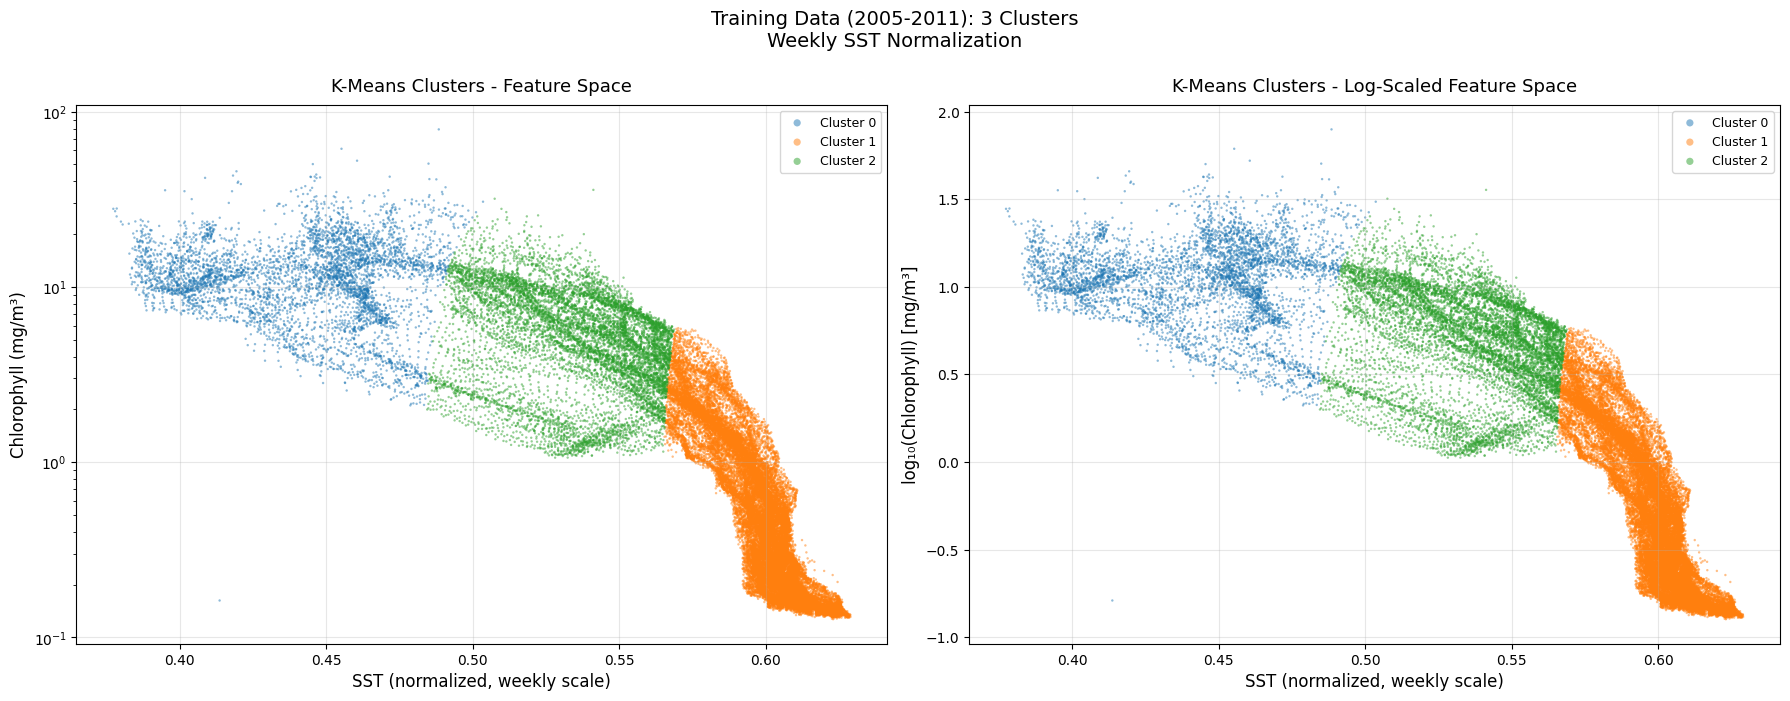

In [27]:
# Visualize feature space
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors_map = {}
for i, cl in enumerate(cluster_labels):
    colors_map[cl] = palette[i]

# Left: Normalized SST vs Chlorophyll
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = f'Cluster {cl}'
    axes[0].scatter(training_sst[mask], training_chlor[mask], 
                    alpha=0.5, s=3, color=color, label=label_text, edgecolors='none')

axes[0].set_xlabel('SST (normalized, weekly scale)', fontsize=12)
axes[0].set_ylabel('Chlorophyll (mg/m³)', fontsize=12)
axes[0].set_title('K-Means Clusters - Feature Space', fontsize=13, pad=10)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best', fontsize=9, markerscale=3)
axes[0].set_yscale('log')

# Right: Normalized SST vs log-transformed chlorophyll
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = f'Cluster {cl}'
    axes[1].scatter(training_sst[mask], np.log10(training_chlor[mask]), 
                    alpha=0.5, s=3, color=color, label=label_text, edgecolors='none')

axes[1].set_xlabel('SST (normalized, weekly scale)', fontsize=12)
axes[1].set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
axes[1].set_title('K-Means Clusters - Log-Scaled Feature Space', fontsize=13, pad=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best', fontsize=9, markerscale=3)

plt.suptitle(f'Training Data ({training_years[0]}-{training_years[-1]}): {n_clusters} Clusters\nWeekly SST Normalization', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

In [28]:
# Print detailed cluster statistics
print("\n" + "=" * 80)
print("TRAINING DATA CLUSTER STATISTICS")
print("=" * 80)

for label in sorted(set(training_labels)):
    mask = training_labels == label
    sst_cluster = training_sst[mask]
    chlor_cluster = training_chlor[mask]
    
    print(f"\n🔵 Cluster {label}:")
    print(f"  Pixels: {mask.sum():,} ({100*mask.sum()/len(mask):.1f}%)")
    print(f"  SST (normalized): {sst_cluster.mean():.4f} ± {sst_cluster.std():.4f}")
    print(f"       Range: [{sst_cluster.min():.4f}, {sst_cluster.max():.4f}]")
    print(f"  Chlorophyll: {chlor_cluster.mean():.6f} ± {chlor_cluster.std():.6f} mg/m³")
    print(f"               Range: [{chlor_cluster.min():.6f}, {chlor_cluster.max():.6f}] mg/m³")
    print(f"  log₁₀(Chlorophyll): {np.log10(chlor_cluster).mean():.4f} ± {np.log10(chlor_cluster).std():.4f}")

print("\n" + "=" * 80)


TRAINING DATA CLUSTER STATISTICS

🔵 Cluster 0:
  Pixels: 4,868 (10.9%)
  SST (normalized): 0.4427 ± 0.0284
       Range: [0.3774, 0.5036]
  Chlorophyll: 12.284660 ± 6.251271 mg/m³
               Range: [0.162370, 79.162941] mg/m³
  log₁₀(Chlorophyll): 1.0329 ± 0.2314

🔵 Cluster 1:
  Pixels: 30,921 (69.2%)
  SST (normalized): 0.5983 ± 0.0132
       Range: [0.5655, 0.6289]
  Chlorophyll: 0.781656 ± 0.859317 mg/m³
               Range: [0.126928, 5.815909] mg/m³
  log₁₀(Chlorophyll): -0.3170 ± 0.4150

🔵 Cluster 2:
  Pixels: 8,920 (20.0%)
  SST (normalized): 0.5355 ± 0.0213
       Range: [0.4845, 0.5687]
  Chlorophyll: 5.850432 ± 3.600483 mg/m³
               Range: [1.060391, 35.756612] mg/m³
  log₁₀(Chlorophyll): 0.6809 ± 0.2862



## 4. Apply Model to New Data

Select a time period to apply the trained clustering model.

In [3]:
# Configuration for new data
apply_year = 2009
apply_start = '2009-07-1'
apply_end = '2009-07-31'

sst_var = 'analysed_sst'
chlor_var = 'chlor_a'
chlor_group = 'geophysical_data'

sst_base_pattern = r"E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_{year}-06-01_{year}-11-30"
chlor_base_pattern = r"E:\satdata\Texas Louisiana Shelf_{year}-06-01_{year}-11-30"

print(f"Applying model to: {apply_start} to {apply_end}")

Applying model to: 2009-07-1 to 2009-07-31


In [4]:
# Load SST data for the period
print("\n" + "=" * 80)
print("LOADING SST DATA")
print("=" * 80)

sst_dir = sst_base_pattern.format(year=apply_year)
all_sst_files = sorted(glob.glob(os.path.join(sst_dir, '*.nc')))
print(f"  Total SST files in {apply_year}: {len(all_sst_files)}")

# Filter by date
sst_files = []
for sst_file in all_sst_files:
    try:
        with xr.open_dataset(sst_file) as ds:
            file_time = pd.to_datetime(ds.time.values[0])
            if pd.Timestamp(apply_start) <= file_time <= pd.Timestamp(apply_end):
                sst_files.append(sst_file)
    except:
        continue

print(f"  Files in period: {len(sst_files)}")

# Load datasets
sst_loader = L3DatasetLoader(variables=[sst_var], bbox=(lon_min, lon_max, lat_min, lat_max))
sst_datasets = sst_loader.load_multiple(sst_files)

# Process SST
sst_list = []
for ds in sst_datasets:
    sst_k = ds[sst_var].values.squeeze()
    sst_c = sst_k - 273.15
    sst_c[(sst_c < -2) | (sst_c > 35)] = np.nan
    sst_list.append(sst_c)

sst_mean = np.nanmean(np.stack(sst_list, axis=0), axis=0)
lat_sst = sst_datasets[0]['lat'].values
lon_sst = sst_datasets[0]['lon'].values

print(f"  SST range: {np.nanmin(sst_mean):.2f} to {np.nanmax(sst_mean):.2f} °C")
print(f"  Valid pixels: {np.sum(~np.isnan(sst_mean))}")


LOADING SST DATA
  Total SST files in 2009: 184
  Files in period: 30
  Files in period: 30
  SST range: 28.15 to 30.42 °C
  Valid pixels: 137002
  SST range: 28.15 to 30.42 °C
  Valid pixels: 137002


In [5]:
# Load chlorophyll data for the period
print("\n" + "=" * 80)
print("LOADING CHLOROPHYLL DATA")
print("=" * 80)

chlor_dir = chlor_base_pattern.format(year=apply_year)
all_chlor_files = glob.glob(os.path.join(chlor_dir, '**', '*.nc'), recursive=True)
print(f"  Total chlorophyll files in {apply_year}: {len(all_chlor_files)}")

# Filter by date (from filename)
chlor_files = []
for chlor_file in all_chlor_files:
    filename = os.path.basename(chlor_file)
    try:
        if 'AQUA_MODIS' in filename or 'MODIS' in filename:
            parts = filename.split('.')
            if len(parts) > 1:
                date_str = parts[1][:8]
                file_date = pd.to_datetime(date_str, format='%Y%m%d')
                if pd.Timestamp(apply_start) <= file_date <= pd.Timestamp(apply_end):
                    chlor_files.append(chlor_file)
    except:
        continue

print(f"  Files in period: {len(chlor_files)}")

if len(chlor_files) > 0:
    # Load datasets
    chlor_loader = L2DatasetLoader(variables=[chlor_var], group=chlor_group)
    chlor_datasets = chlor_loader.load_multiple(chlor_files)
    
    # Extract data
    try:
        extractor = GPUDataExtractor(variables=[chlor_var])
        lon_chlor, lat_chlor, chlor_data = extractor.extract(chlor_datasets)
        chlor_flat = chlor_data[chlor_var]
        print(f"  GPU extraction: {len(chlor_flat)} points")
    except Exception as e:
        print(f"  GPU failed, using CPU...")
        all_lons, all_lats, all_chlor = [], [], []
        for ds in chlor_datasets:
            lat = ds['lat'].values.flatten()
            lon = ds['lon'].values.flatten()
            chlor = ds[chlor_var].values.flatten()
            valid = (~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(chlor) & (chlor > 0))
            all_lats.extend(lat[valid])
            all_lons.extend(lon[valid])
            all_chlor.extend(chlor[valid])
        lat_chlor = np.array(all_lats)
        lon_chlor = np.array(all_lons)
        chlor_flat = np.array(all_chlor)
        print(f"  CPU extraction: {len(chlor_flat)} points")
else:
    print("  ⚠ No chlorophyll files found")
    chlor_flat = np.array([])
    lat_chlor = np.array([])
    lon_chlor = np.array([])


LOADING CHLOROPHYLL DATA
  Total chlorophyll files in 2009: 284
  Files in period: 50
  GPU extraction: 14552214 points
  GPU extraction: 14552214 points


In [6]:
# Grid the data
print("\n" + "=" * 80)
print("GRIDDING DATA")
print("=" * 80)

# Bin chlorophyll
clip_mask = ((lon_chlor >= lon_min) & (lon_chlor <= lon_max) &
             (lat_chlor >= lat_min) & (lat_chlor <= lat_max))

chlor_binned, _, _, _ = binned_statistic_2d(
    lat_chlor[clip_mask], lon_chlor[clip_mask], chlor_flat[clip_mask],
    statistic='mean',
    bins=[lat_bins, lon_bins],
    range=[[lat_min, lat_max], [lon_min, lon_max]]
)

print(f"  Valid chlorophyll pixels: {np.sum(~np.isnan(chlor_binned))}")

# Interpolate SST
sst_interpolator = RegularGridInterpolator(
    (lat_sst, lon_sst), sst_mean,
    method='linear', bounds_error=False, fill_value=np.nan
)

lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)
points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
sst_regridded = sst_interpolator(points).reshape(chlor_binned.shape)

print(f"  Valid SST pixels: {np.sum(~np.isnan(sst_regridded))}")


GRIDDING DATA
  Valid chlorophyll pixels: 44164
  Valid SST pixels: 44898


In [7]:
# Normalize SST using weekly statistics (approximate for the period)
print("\n" + "=" * 80)
print("NORMALIZING SST")
print("=" * 80)

# For simplicity, use min/max of the current period
# In a production setting, you would match to the specific week from training
sst_min_period = np.nanmin(sst_regridded)
sst_max_period = np.nanmax(sst_regridded)
sst_range_period = sst_max_period - sst_min_period

print(f"  Period SST range: [{sst_min_period:.2f}, {sst_max_period:.2f}] °C (range: {sst_range_period:.2f}°C)")

# Normalize SST
sst_normalized = (sst_regridded - sst_min_period) / sst_range_period if sst_range_period > 0 else sst_regridded * 0

print(f"  Normalized SST range: [{np.nanmin(sst_normalized):.4f}, {np.nanmax(sst_normalized):.4f}]")


NORMALIZING SST
  Period SST range: [28.16, 30.42] °C (range: 2.26°C)
  Normalized SST range: [0.0000, 1.0000]


In [8]:
# Apply clustering model
print("\n" + "=" * 80)
print("APPLYING CLUSTERING MODEL")
print("=" * 80)

valid_mask = ~np.isnan(sst_normalized) & ~np.isnan(chlor_binned)
n_valid = np.sum(valid_mask)
print(f"  Pixels with both SST and chlorophyll: {n_valid}")

if n_valid > 0:
    sst_valid = sst_normalized[valid_mask]
    chlor_valid = chlor_binned[valid_mask]
    
    # Create features
    features = np.column_stack([sst_valid, np.log10(chlor_valid)])
    features_scaled = scaler.transform(features)
    
    # Predict clusters
    labels = kmeans.predict(features_scaled)
    
    n_clusters_found = len(set(labels))
    
    print(f"  Clusters assigned: {n_clusters_found}")
    
    # Create cluster map
    cluster_map = np.full(sst_normalized.shape, np.nan)
    cluster_map[valid_mask] = labels
else:
    print("  ⚠ No valid data to cluster")
    labels = np.array([])
    cluster_map = np.full(sst_normalized.shape, np.nan)


APPLYING CLUSTERING MODEL
  Pixels with both SST and chlorophyll: 43721
  Clusters assigned: 3


## 5. Visualize Results

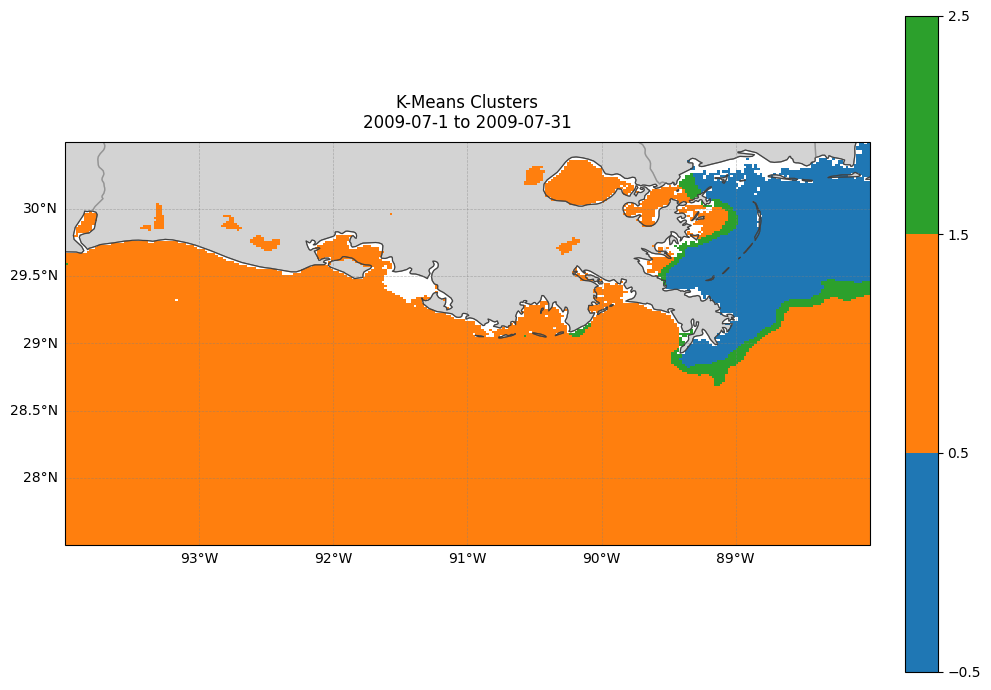

In [35]:
if n_valid > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), subplot_kw={'projection': ccrs.PlateCarree()})

    # Prepare plot data
    unique_labels_new = sorted(set(labels))
    
    plot_map = np.full_like(cluster_map, np.nan)
    plot_map[valid_mask] = labels

    # Cluster map
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    cluster_plot = ax.pcolormesh(lon_edges, lat_edges, plot_map,
                                 cmap=cmap, norm=norm, shading='auto',
                                 transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = gl.right_labels = False

    plt.colorbar(cluster_plot, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'K-Means Clusters\n{apply_start} to {apply_end}', fontsize=12, pad=10)

    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize")

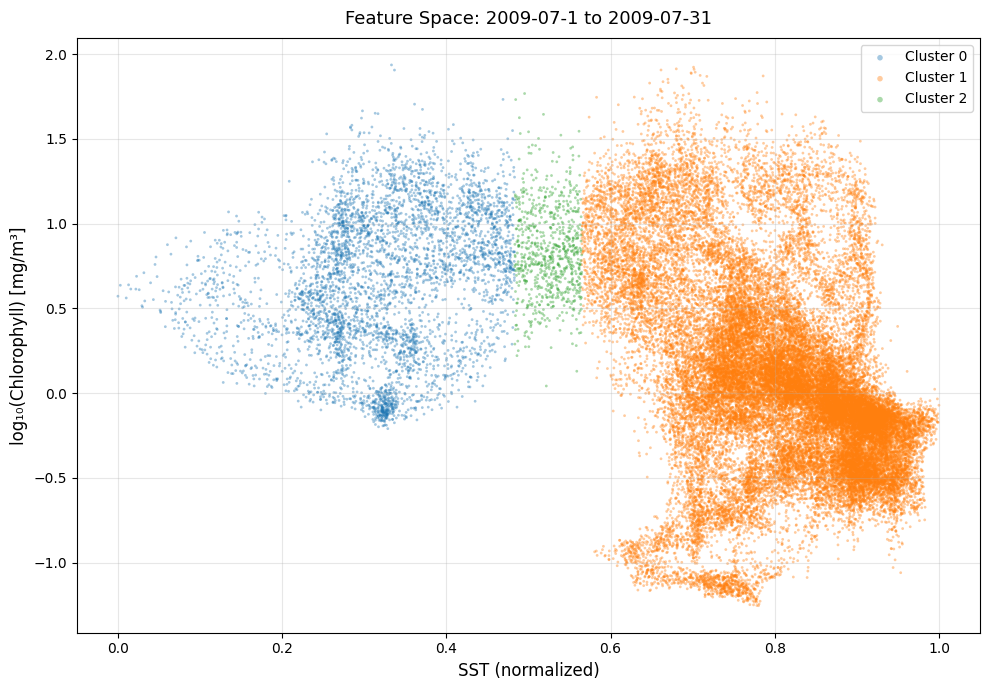

In [36]:
# Feature space for new data
if n_valid > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    
    for cl in unique_labels_new:
        mask = labels == cl
        color = colors_map.get(cl, '#808080')
        label_text = f'Cluster {cl}'
        ax.scatter(sst_valid[mask], np.log10(chlor_valid[mask]), 
                   alpha=0.4, s=4, color=color, label=label_text, edgecolors='none')
    
    ax.set_xlabel('SST (normalized)', fontsize=12)
    ax.set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
    ax.set_title(f'Feature Space: {apply_start} to {apply_end}', fontsize=13, pad=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=10, markerscale=2)
    
    plt.tight_layout()
    plt.show()

In [37]:
# Print cluster statistics for new data
if n_valid > 0:
    print("\n" + "=" * 80)
    print(f"CLUSTER STATISTICS: {apply_start.upper()} TO {apply_end.upper()}")
    print("=" * 80)
    
    for label in sorted(set(labels)):
        mask = labels == label
        sst_cluster = sst_valid[mask]
        chlor_cluster = chlor_valid[mask]
        
        print(f"\n🔵 Cluster {label}:")
        print(f"  Pixels: {mask.sum():,} ({100*mask.sum()/len(mask):.1f}%)")
        print(f"  SST (normalized): {sst_cluster.mean():.4f} ± {sst_cluster.std():.4f}")
        print(f"       Range: [{sst_cluster.min():.4f}, {sst_cluster.max():.4f}]")
        print(f"  Chlorophyll: {chlor_cluster.mean():.6f} ± {chlor_cluster.std():.6f} mg/m³")
        print(f"               Range: [{chlor_cluster.min():.6f}, {chlor_cluster.max():.6f}] mg/m³")
        print(f"  log₁₀(Chlorophyll): {np.log10(chlor_cluster).mean():.4f} ± {np.log10(chlor_cluster).std():.4f}")
    
    print("\n" + "=" * 80)


CLUSTER STATISTICS: 2009-07-1 TO 2009-07-31

🔵 Cluster 0:
  Pixels: 4,447 (10.2%)
  SST (normalized): 0.3212 ± 0.0903
       Range: [0.0000, 0.4833]
  Chlorophyll: 6.852510 ± 6.501677 mg/m³
               Range: [0.617325, 86.311951] mg/m³
  log₁₀(Chlorophyll): 0.6551 ± 0.4131

🔵 Cluster 1:
  Pixels: 38,520 (88.1%)
  SST (normalized): 0.8073 ± 0.0961
       Range: [0.5649, 1.0000]
  Chlorophyll: 2.894808 ± 5.500473 mg/m³
               Range: [0.055742, 83.685158] mg/m³
  log₁₀(Chlorophyll): 0.0620 ± 0.5505

🔵 Cluster 2:
  Pixels: 754 (1.7%)
  SST (normalized): 0.5257 ± 0.0240
       Range: [0.4833, 0.5649]
  Chlorophyll: 8.289334 ± 6.094152 mg/m³
               Range: [1.101821, 58.523603] mg/m³
  log₁₀(Chlorophyll): 0.8355 ± 0.2597



## 6. Summary

The trained K-Means model can identify oceanic regimes based on normalized SST and chlorophyll patterns. The model was trained on 2010-2011 data with weekly SST normalization and can be applied to any new time period with SST and chlorophyll measurements.

**Next Steps:**
- Apply to different time periods
- Compare cluster distributions across seasons/years
- Analyze environmental drivers of each cluster
- Export cluster masks for further analysis

## 7. Combined Analysis: K-Means + DBSCAN Binary Maps

Compare K-Means and DBSCAN clustering by creating binary maps and combining them.

In [9]:
# Load DBSCAN model
dbscan_model_path = r"E:\satdata\Custom\dbscan_model_optimal_2005_2011.pkl"

print("Loading DBSCAN model...")
with open(dbscan_model_path, 'rb') as f:
    dbscan_model_data = pickle.load(f)

# Extract DBSCAN components
dbscan_model = dbscan_model_data['dbscan_model']
dbscan_scaler = dbscan_model_data['scaler']

print("✓ DBSCAN model loaded")
print(f"  DBSCAN clusters: {dbscan_model_data['n_clusters']}")
print(f"  DBSCAN eps: {dbscan_model_data['eps']:.4f}, min_samples: {dbscan_model_data['min_samples']}")

Loading DBSCAN model...
✓ DBSCAN model loaded
  DBSCAN clusters: 640
  DBSCAN eps: 0.0142, min_samples: 4


In [10]:
# Apply DBSCAN to the same data that K-means was applied to
# Note: We already have sst_valid and chlor_valid from the K-means prediction above
# But DBSCAN uses raw (non-normalized) SST

print("\n" + "=" * 80)
print("APPLYING DBSCAN TO SAME DATA")
print("=" * 80)

# For DBSCAN, we need actual SST values (not normalized)
# Get the actual SST values that correspond to our valid mask
sst_actual_valid = sst_regridded[valid_mask]  # This is in Celsius

# Create DBSCAN features (raw SST, log chlorophyll)
dbscan_features = np.column_stack([sst_actual_valid, np.log10(chlor_valid)])
dbscan_features_scaled = dbscan_scaler.transform(dbscan_features)

# Predict with DBSCAN
dbscan_labels = dbscan_model.fit_predict(dbscan_features_scaled)

n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_dbscan_noise = np.sum(dbscan_labels == -1)

print(f"  DBSCAN clusters found: {n_dbscan_clusters}")
print(f"  DBSCAN noise points: {n_dbscan_noise} ({100*n_dbscan_noise/len(dbscan_labels):.1f}%)")
print(f"  Label range: {dbscan_labels.min()} to {dbscan_labels.max()}")

# Create DBSCAN cluster map
dbscan_cluster_map = np.full(sst_normalized.shape, np.nan)
dbscan_cluster_map[valid_mask] = dbscan_labels


APPLYING DBSCAN TO SAME DATA
  DBSCAN clusters found: 980
  DBSCAN noise points: 9192 (21.0%)
  Label range: -1 to 979


In [31]:
# Create binary maps

print("\n" + "=" * 80)
print("CREATING BINARY MAPS")
print("=" * 80)

# K-Means binary map: clusters 0 and 2 become 0, cluster 1 becomes 1
kmeans_binary = np.full(cluster_map.shape, np.nan)
for i, label_val in enumerate(labels):
    if label_val in [0, 2]:
        kmeans_binary.flat[np.where(valid_mask.flat)[0][i]] = 0
    elif label_val == 1:
        kmeans_binary.flat[np.where(valid_mask.flat)[0][i]] = 1

kmeans_binary_count_1 = np.sum(kmeans_binary == 1)
kmeans_binary_count_0 = np.sum(kmeans_binary == 0)
print(f"K-Means binary map:")
print(f"  Cluster 0,2 → 0: {kmeans_binary_count_0} pixels")
print(f"  Cluster 1 → 1: {kmeans_binary_count_1} pixels")

# DBSCAN binary map: clusters 350-600 become 1, below 350 become 0
dbscan_binary = np.full(dbscan_cluster_map.shape, np.nan)
for i, label_val in enumerate(dbscan_labels):
    if 400 <= label_val <= 1000:
        dbscan_binary.flat[np.where(valid_mask.flat)[0][i]] = 1
    elif label_val < 400:
        dbscan_binary.flat[np.where(valid_mask.flat)[0][i]] = 0

dbscan_binary_count_1 = np.sum(dbscan_binary == 1)
dbscan_binary_count_0 = np.sum(dbscan_binary == 0)
print(f"\nDBSCAN binary map:")
print(f"  Clusters 350-900 → 1: {dbscan_binary_count_1} pixels")
print(f"  Clusters <350 → 0: {dbscan_binary_count_0} pixels")

# Multiply the binary maps
combined_binary = kmeans_binary * dbscan_binary

combined_count_1 = np.sum(combined_binary == 1)
combined_count_0 = np.sum(combined_binary == 0)
print(f"\nCombined binary map (K-Means × DBSCAN):")
print(f"  Value 1: {combined_count_1} pixels")
print(f"  Value 0: {combined_count_0} pixels")


CREATING BINARY MAPS
K-Means binary map:
  Cluster 0,2 → 0: 5201 pixels
  Cluster 1 → 1: 38520 pixels
K-Means binary map:
  Cluster 0,2 → 0: 5201 pixels
  Cluster 1 → 1: 38520 pixels

DBSCAN binary map:
  Clusters 350-900 → 1: 4318 pixels
  Clusters <350 → 0: 39403 pixels

Combined binary map (K-Means × DBSCAN):
  Value 1: 3058 pixels
  Value 0: 40663 pixels

DBSCAN binary map:
  Clusters 350-900 → 1: 4318 pixels
  Clusters <350 → 0: 39403 pixels

Combined binary map (K-Means × DBSCAN):
  Value 1: 3058 pixels
  Value 0: 40663 pixels


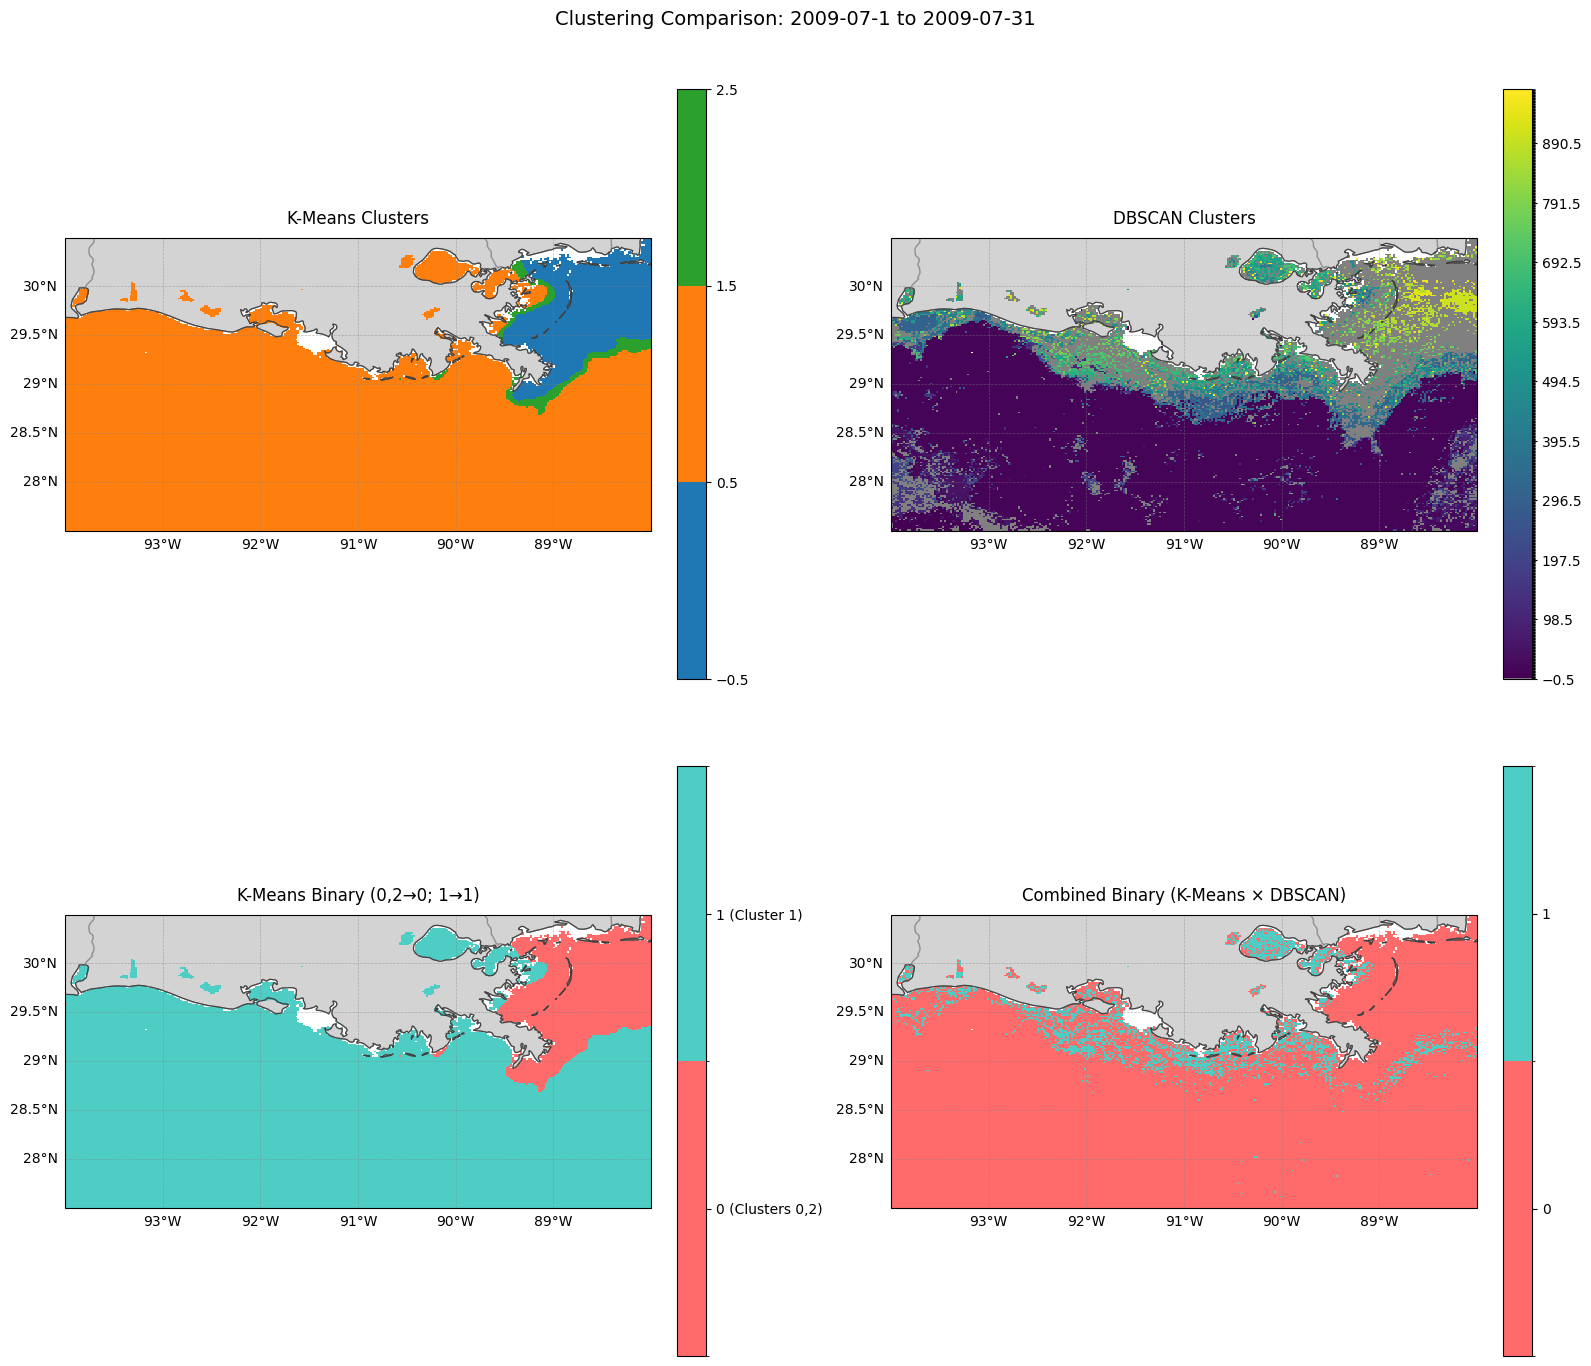

In [32]:
# Visualize all maps side-by-side
fig, axes = plt.subplots(2, 2, figsize=(16, 14), subplot_kw={'projection': ccrs.PlateCarree()})

# K-Means colormap (recreate from training)
palette = ['#1f77b4', '#ff7f0e', '#2ca02c']
kmeans_cmap = ListedColormap(palette[:n_clusters])
kmeans_bounds = np.arange(0, n_clusters + 1) - 0.5
kmeans_norm = BoundaryNorm(kmeans_bounds, kmeans_cmap.N)

# Binary colormap
binary_cmap = ListedColormap(['#FF6B6B', '#4ECDC4'])  # Red=0, Teal=1
binary_norm = BoundaryNorm([0, 0.5, 1], binary_cmap.N)

# 1. K-Means original clusters
ax = axes[0, 0]
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
plot_map = np.full_like(cluster_map, np.nan)
plot_map[valid_mask] = labels
km_plot = ax.pcolormesh(lon_edges, lat_edges, plot_map, cmap=kmeans_cmap, norm=kmeans_norm, 
                         shading='auto', transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = gl.right_labels = False
plt.colorbar(km_plot, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('K-Means Clusters', fontsize=12, pad=10)

# 2. DBSCAN original clusters
ax = axes[0, 1]
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
# Create a colormap for DBSCAN (just show distinct colors)
unique_dbscan = sorted([l for l in set(dbscan_labels) if l != -1])
dbscan_palette = plt.cm.viridis(np.linspace(0, 1, len(unique_dbscan)))
dbscan_cmap_colors = ['#808080'] + [rgb2hex(c) for c in dbscan_palette]
dbscan_cmap = ListedColormap(dbscan_cmap_colors)
dbscan_norm = BoundaryNorm(np.arange(-0.5, len(unique_dbscan) + 1.5), dbscan_cmap.N)
plot_map_dbscan = np.full_like(dbscan_cluster_map, np.nan)
dbscan_label_to_idx = {-1: 0}
for i, cl in enumerate(unique_dbscan):
    dbscan_label_to_idx[cl] = i + 1
for i, label_val in enumerate(dbscan_labels):
    plot_map_dbscan.flat[np.where(valid_mask.flat)[0][i]] = dbscan_label_to_idx[label_val]
db_plot = ax.pcolormesh(lon_edges, lat_edges, plot_map_dbscan, cmap=dbscan_cmap, norm=dbscan_norm,
                         shading='auto', transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = gl.right_labels = False
plt.colorbar(db_plot, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('DBSCAN Clusters', fontsize=12, pad=10)

# 3. K-Means binary
ax = axes[1, 0]
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
km_bin_plot = ax.pcolormesh(lon_edges, lat_edges, kmeans_binary, cmap=binary_cmap, norm=binary_norm,
                              shading='auto', transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = gl.right_labels = False
cbar = plt.colorbar(km_bin_plot, ax=ax, fraction=0.046, pad=0.04, ticks=[0.25, 0.75])
cbar.ax.set_yticklabels(['0 (Clusters 0,2)', '1 (Cluster 1)'])
ax.set_title('K-Means Binary (0,2→0; 1→1)', fontsize=12, pad=10)

# 4. Combined binary map
ax = axes[1, 1]
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
comb_plot = ax.pcolormesh(lon_edges, lat_edges, combined_binary, cmap=binary_cmap, norm=binary_norm,
                           shading='auto', transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = gl.right_labels = False
cbar = plt.colorbar(comb_plot, ax=ax, fraction=0.046, pad=0.04, ticks=[0.25, 0.75])
cbar.ax.set_yticklabels(['0', '1'])
ax.set_title('Combined Binary (K-Means × DBSCAN)', fontsize=12, pad=10)

plt.suptitle(f'Clustering Comparison: {apply_start} to {apply_end}', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

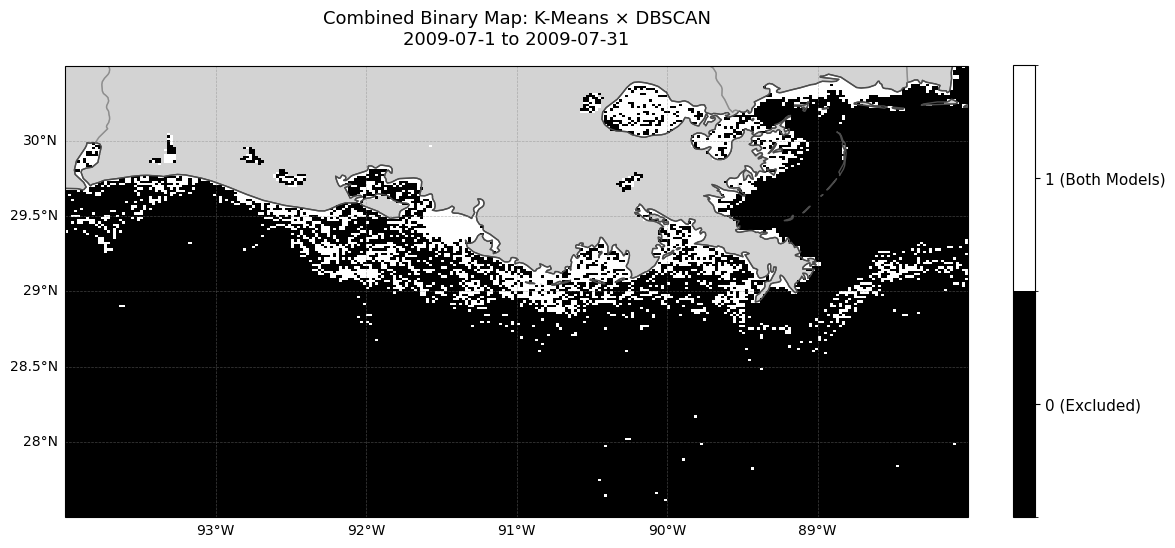


Combined map captures 3058 pixels where both models agree


In [44]:
# Show black & white combined binary map
fig, ax = plt.subplots(1, 1, figsize=(12, 9), subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Create a pure B/W colormap (0→white, 1→black)
bw_cmap = ListedColormap(['black', 'white'])

bw_plot = ax.pcolormesh(
    lon_edges, lat_edges, combined_binary,
    cmap=bw_cmap, norm=binary_norm,
    shading='auto', transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.6)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = gl.right_labels = False

# Adjust layout first to get accurate axes positions
plt.tight_layout()

# Create colorbar with shrink parameter to match map height
cbar = plt.colorbar(bw_plot, ax=ax, shrink=0.52, pad=0.04, ticks=[0.25, 0.75])
cbar.ax.set_yticklabels(['0 (Excluded)', '1 (Both Models)'], fontsize=11)

ax.set_title(
    f'Combined Binary Map: K-Means × DBSCAN\n{apply_start} to {apply_end}',
    fontsize=13, pad=15
)

plt.show()

print(f"\nCombined map captures {combined_count_1} pixels where both models agree")